# Advertised Salary Prediction

## Canadian Job Bank — January 2025

This notebook develops regression models to estimate the midpoint of an advertised hourly salary range using occupation, location, employment conditions, education, experience, and vacancy information.

Only postings that passed the salary-quality checks are included. Original salary fields are excluded from the predictors because the target was calculated from them, and including them would cause data leakage.

In [1]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

sns.set_theme(style="whitegrid")

In [3]:
processed_path = Path(
    "../data/processed/job_bank_jan_2025_clean.parquet"
)

jobs = pd.read_parquet(processed_path)

print("Rows:", f"{jobs.shape[0]:,}")
print("Columns:", jobs.shape[1])

Rows: 101,570
Columns: 68


In [4]:
target_column = "hourly_salary_midpoint"

numeric_features = [
    "vacancy_count"
]

categorical_features = [
    "province_territory",
    "noc21_code_name",
    "employment_type",
    "employment_term",
    "education_los",
    "experience_level"
]

feature_columns = numeric_features + categorical_features

In [5]:
model_data = jobs.loc[
    jobs["salary_valid_for_analysis"],
    feature_columns + [target_column]
].copy()

print("Modelling rows:", f"{len(model_data):,}")
model_data.head()

Modelling rows: 52,896


,vacancy_count,province_territory,noc21_code_name,employment_type,employment_term,education_los,experience_level,hourly_salary_midpoint
3,30,Nova Scotia,Nursery and greenhouse labourers,Full time,Seasonal employment,"No degree, certificate or diploma",No experience,15.470000
12,1,Alberta,Security guards and related security service o...,Full time,Permanent employment,NaN,NaN,28.625962
14,1,Alberta,Retail salespersons and visual merchandisers,Full time,NaN,NaN,NaN,16.500000
19,1,Alberta,"Senior managers - health, education, social an...",Full time,Permanent employment,NaN,NaN,37.019231
22,1,Alberta,Heavy equipment operators,Full time,NaN,NaN,NaN,35.000000


In [6]:
feature_audit = pd.DataFrame({
    "data_type": model_data[feature_columns].dtypes.astype(str),
    "missing_count": model_data[feature_columns].isna().sum(),
    "missing_percentage": (
        model_data[feature_columns].isna().mean() * 100
    ).round(1),
    "unique_values": model_data[feature_columns].nunique()
})

feature_audit

,data_type,missing_count,missing_percentage,unique_values
vacancy_count,int64,0,0.0,46
province_territory,str,65,0.1,13
noc21_code_name,str,421,0.8,485
employment_type,str,2636,5.0,3
employment_term,str,10475,19.8,4
education_los,str,27229,51.5,11
experience_level,str,27229,51.5,7


In [7]:
X = model_data[feature_columns]
y = model_data[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", f"{len(X_train):,}")
print("Testing rows:", f"{len(X_test):,}")

Training rows: 42,316
Testing rows: 10,580


In [8]:
baseline_model = DummyRegressor(
    strategy="median"
)

baseline_model.fit(X_train, y_train)

baseline_predictions = baseline_model.predict(X_test)

In [9]:
baseline_results = pd.DataFrame({
    "Model": ["Median baseline"],
    "MAE": [
        mean_absolute_error(
            y_test,
            baseline_predictions
        )
    ],
    "RMSE": [
        mean_squared_error(
            y_test,
            baseline_predictions
        ) ** 0.5
    ],
    "R2": [
        r2_score(
            y_test,
            baseline_predictions
        )
    ]
}).round(3)

baseline_results

,Model,MAE,RMSE,R2
0,Median baseline,8.845,15.591,-0.047


## Multiple Linear Regression

A preprocessing pipeline is used to prevent information leakage:

- Missing numeric values are replaced with the training-set median.
- Numeric features are standardized.
- Missing categorical values become a `Not reported` category.
- Categorical variables are one-hot encoded.
- Rare categories with fewer than 20 observations are grouped together.

All preprocessing is learned using only the training data.

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression

In [11]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [12]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="constant",
                fill_value="Not reported"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="infrequent_if_exist",
                min_frequency=20
            )
        )
    ]
)

In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [14]:
linear_regression_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "regressor",
            LinearRegression()
        )
    ]
)

linear_regression_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['vacancy_count','province_territory','noc21_code_name',..., 'employment_term','education_los','experience_level']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` wil

In [15]:
linear_predictions = linear_regression_model.predict(
    X_test
)

In [16]:
linear_results = pd.DataFrame({
    "Model": ["Multiple linear regression"],
    "MAE": [
        mean_absolute_error(
            y_test,
            linear_predictions
        )
    ],
    "RMSE": [
        mean_squared_error(
            y_test,
            linear_predictions
        ) ** 0.5
    ],
    "R2": [
        r2_score(
            y_test,
            linear_predictions
        )
    ]
}).round(3)

model_results = pd.concat(
    [
        baseline_results,
        linear_results
    ],
    ignore_index=True
)

model_results

,Model,MAE,RMSE,R2
0,Median baseline,8.845,15.591,-0.047
1,Multiple linear regression,5.514,9.827,0.584


In [17]:
baseline_mae = baseline_results.loc[0, "MAE"]
linear_mae = linear_results.loc[0, "MAE"]

mae_improvement_percentage = (
    (baseline_mae - linear_mae)
    / baseline_mae
    * 100
)

print(
    "MAE improvement over baseline:",
    f"{mae_improvement_percentage:.1f}%"
)

MAE improvement over baseline: 37.7%


In [18]:
prediction_summary = pd.Series(
    linear_predictions
).describe(
    percentiles=[0.01, 0.50, 0.99]
).round(2)

prediction_summary

count    10580.00
mean        29.04
std         11.70
min          8.95
1%          15.76
50%         26.79
99%         61.63
max        185.79
dtype: float64

### Initial Model Performance

Multiple linear regression substantially outperformed the median baseline. On the test set, its mean absolute error was approximately $5.51 per hour, compared with $8.85 for the baseline—a reduction of approximately 37.7%.

The model explained approximately 58.4% of observed salary variation. Its RMSE was higher than its MAE, indicating that a smaller number of postings produced relatively large errors. Cross-validation and residual analysis are therefore required before drawing final conclusions.

In [19]:
from sklearn.model_selection import KFold, cross_validate

cross_validation = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_validate(
    linear_regression_model,
    X,
    y,
    cv=cross_validation,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    },
    n_jobs=1
)

In [20]:
cv_summary = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2"],

    "Mean score": [
        -cv_scores["test_MAE"].mean(),
        -cv_scores["test_RMSE"].mean(),
        cv_scores["test_R2"].mean()
    ],

    "Standard deviation": [
        cv_scores["test_MAE"].std(),
        cv_scores["test_RMSE"].std(),
        cv_scores["test_R2"].std()
    ]
}).round(3)

cv_summary

,Metric,Mean score,Standard deviation
0,MAE,5.505,0.076
1,RMSE,10.066,0.436
2,R2,0.574,0.025


In [21]:
prediction_diagnostics = pd.DataFrame({
    "actual_salary": y_test.to_numpy(),
    "predicted_salary": linear_predictions
})

prediction_diagnostics["residual"] = (
    prediction_diagnostics["actual_salary"]
    - prediction_diagnostics["predicted_salary"]
)

prediction_diagnostics["absolute_error"] = (
    prediction_diagnostics["residual"].abs()
)

prediction_diagnostics.head()

,actual_salary,predicted_salary,residual,absolute_error
0,19.48,19.553955,-0.073955,0.073955
1,35.00,32.594081,2.405919,2.405919
2,23.00,21.768530,1.231470,1.231470
3,28.75,30.700504,-1.950504,1.950504
4,28.85,29.929857,-1.079857,1.079857


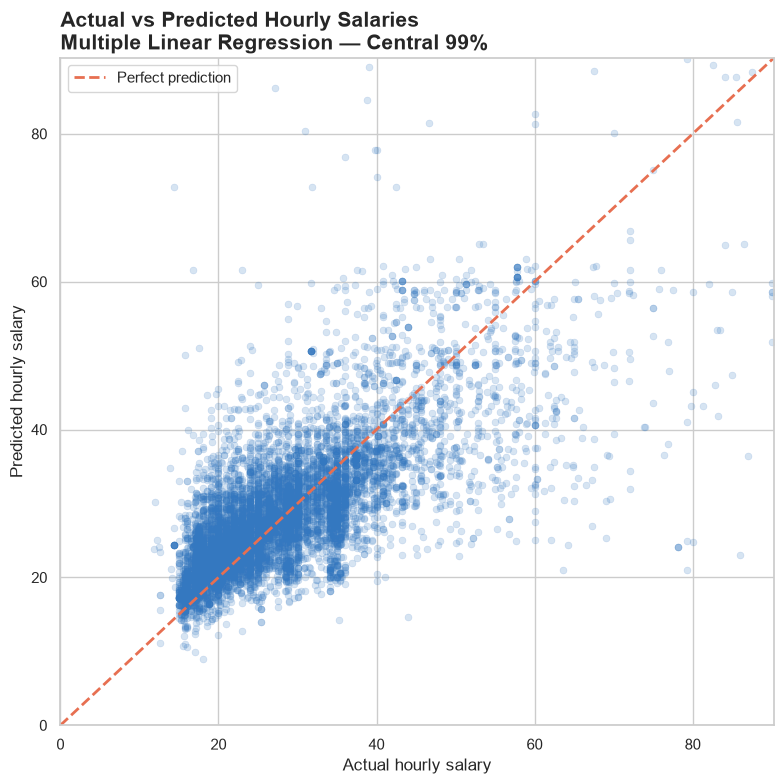

In [22]:
plot_limit = max(
    prediction_diagnostics["actual_salary"].quantile(0.99),
    prediction_diagnostics["predicted_salary"].quantile(0.99)
)

plot_data = prediction_diagnostics[
    prediction_diagnostics["actual_salary"].le(plot_limit)
    & prediction_diagnostics["predicted_salary"].le(plot_limit)
]

fig, ax = plt.subplots(figsize=(8, 8))

sns.scatterplot(
    data=plot_data,
    x="actual_salary",
    y="predicted_salary",
    alpha=0.20,
    s=25,
    color="#3478C0",
    edgecolor=None,
    ax=ax
)

ax.plot(
    [0, plot_limit],
    [0, plot_limit],
    linestyle="--",
    color="#E76F51",
    linewidth=2,
    label="Perfect prediction"
)

ax.set_title(
    "Actual vs Predicted Hourly Salaries\n"
    "Multiple Linear Regression — Central 99%",
    loc="left",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Actual hourly salary")
ax.set_ylabel("Predicted hourly salary")
ax.set_xlim(0, plot_limit)
ax.set_ylim(0, plot_limit)
ax.legend()

plt.tight_layout()

figures_path = Path("../reports/figures")
figures_path.mkdir(parents=True, exist_ok=True)

plt.savefig(
    figures_path / "linear_regression_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
prediction_diagnostics["actual_salary_band"] = pd.qcut(
    prediction_diagnostics["actual_salary"],
    q=4,
    duplicates="drop"
)

error_by_salary_band = (
    prediction_diagnostics
    .groupby(
        "actual_salary_band",
        observed=True
    )
    .agg(
        posting_count=("actual_salary", "count"),
        actual_median=("actual_salary", "median"),
        predicted_median=("predicted_salary", "median"),
        MAE=("absolute_error", "mean"),
        average_residual=("residual", "mean")
    )
    .round(2)
)

error_by_salary_band

,posting_count,actual_median,predicted_median,MAE,average_residual
actual_salary_band,,,,,
"(11.874, 20.0]",2891,18.00,20.90,4.02,-3.74
"(20.0, 25.24]",2409,23.00,24.96,3.84,-2.73
"(25.24, 34.1]",2691,29.00,29.02,4.25,-0.26
"(34.1, 288.462]",2589,39.97,35.97,10.05,6.90


### Regression Diagnostics

The model performs best for salaries near the centre of the distribution. Its average residual was only approximately -$0.26 for postings between $25.24 and $34.10 per hour.

However, the model systematically overpredicted salaries in the two lowest bands and underpredicted the highest salary band by approximately $6.90 per hour. MAE increased to approximately $10.05 in the highest band, compared with around $4 in the lower three bands.

The actual-versus-predicted chart confirms that predictions are compressed toward the centre of the salary distribution. Consequently, the model is useful for estimating typical advertised salaries but is less reliable for unusually high-paying positions.

### Cross-Validation Findings

Five-fold cross-validation produced an average MAE of approximately $5.51 per hour and an average R² of 0.574. The small standard deviations indicate that performance remained stable across the five validation folds.

These results are close to the original test-set results, suggesting that the model generalizes consistently within the January 2025 dataset. However, testing on later months will eventually provide a stronger measure of real-world generalization.

## K-Nearest Neighbours Regression

KNN regression estimates a salary using postings with similar feature values. Because KNN calculates distances between observations, numeric variables must be scaled and categorical variables must be encoded.

For computational practicality, KNN is evaluated on a reproducible sample of 8,000 postings. Detailed five-digit occupations are converted into broader two-digit NOC groups to reduce dimensionality. All comparison models use the same sample and train/test split.

In [24]:
knn_columns = [
    "vacancy_count",
    "province_territory",
    "noc21_code",
    "employment_type",
    "employment_term",
    "education_los",
    "experience_level",
    target_column
]

knn_data = jobs.loc[
    jobs["salary_valid_for_analysis"],
    knn_columns
].copy()

knn_data["noc_major_group"] = (
    knn_data["noc21_code"]
    .round()
    .astype("Int64")
    .astype("string")
    .str.zfill(5)
    .str[:2]
)

knn_data[
    ["noc21_code", "noc_major_group"]
].head()

,noc21_code,noc_major_group
3,85103.0,85
12,64410.0,64
14,64100.0,64
19,13.0,00
22,73400.0,73


In [25]:
KNN_SAMPLE_SIZE = 8000

knn_sample = knn_data.sample(
    n=min(KNN_SAMPLE_SIZE, len(knn_data)),
    random_state=42
)

knn_numeric_features = [
    "vacancy_count"
]

knn_categorical_features = [
    "province_territory",
    "noc_major_group",
    "employment_type",
    "employment_term",
    "education_los",
    "experience_level"
]

knn_feature_columns = (
    knn_numeric_features
    + knn_categorical_features
)

X_knn = knn_sample[knn_feature_columns]
y_knn = knn_sample[target_column]

X_knn_train, X_knn_test, y_knn_train, y_knn_test = train_test_split(
    X_knn,
    y_knn,
    test_size=0.20,
    random_state=42
)

print("KNN training rows:", f"{len(X_knn_train):,}")
print("KNN testing rows:", f"{len(X_knn_test):,}")

KNN training rows: 6,400
KNN testing rows: 1,600


In [26]:
knn_numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

knn_categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="constant",
                fill_value="Not reported"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

knn_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            knn_numeric_pipeline,
            knn_numeric_features
        ),
        (
            "categorical",
            knn_categorical_pipeline,
            knn_categorical_features
        )
    ]
)

In [27]:
# Recreate X and y after cleaning the missing values
X_knn = knn_data[knn_feature_columns].copy()
y_knn = knn_data[target_column].copy()

X_knn_train, X_knn_test, y_knn_train, y_knn_test = train_test_split(
    X_knn,
    y_knn,
    test_size=0.20,
    random_state=42
)

print("Training rows:", len(X_knn_train))
print("Testing rows:", len(X_knn_test))
print("\nMissing training values:")
print(X_knn_train.isna().sum())

Training rows: 42316
Testing rows: 10580

Missing training values:
vacancy_count             0
province_territory       56
noc_major_group         341
employment_type        2100
employment_term        8339
education_los         21689
experience_level      21689
dtype: int64


In [28]:
import numpy as np

# Convert pandas missing values into values scikit-learn can process
for column in knn_categorical_features:
    knn_data[column] = (
        knn_data[column]
        .astype("string")
        .fillna("Not reported")
        .astype(str)
    )

knn_data["vacancy_count"] = pd.to_numeric(
    knn_data["vacancy_count"],
    errors="coerce"
).astype(float)

print(knn_data[knn_feature_columns].isna().sum())

vacancy_count         0
province_territory    0
noc_major_group       0
employment_type       0
employment_term       0
education_los         0
experience_level      0
dtype: int64


In [29]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.base import clone

knn_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(knn_preprocessor)
        ),
        (
            "regressor",
            KNeighborsRegressor(
                p=2,
                n_jobs=-1
            )
        )
    ]
)

knn_parameter_grid = {
    "regressor__n_neighbors": [5, 15, 30],
    "regressor__weights": ["uniform", "distance"]
}

knn_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_parameter_grid,
    scoring="neg_mean_absolute_error",
    cv=3,
    n_jobs=-1,
    verbose=1
)

knn_search.fit(
    X_knn_train,
    y_knn_train
)

print("Best parameters:", knn_search.best_params_)
print(
    "Best cross-validation MAE:",
    f"${-knn_search.best_score_:.2f}"
)

Fitting 3 folds for each of 6 candidates, totalling 18 fits


ValueError: 
All the 18 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
18 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\vijda\OneDrive\Desktop\DSI_Class\repos\canadian-job-market-intelligence\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\vijda\OneDrive\Desktop\DSI_Class\repos\canadian-job-market-intelligence\.venv\Lib\site-packages\sklearn\base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\vijda\OneDrive\Desktop\DSI_Class\repos\canadian-job-market-intelligence\.venv\Lib\site-packages\sklearn\pipeline.py", line 636, in fit
    Xt = self._fit(
        X, y, routed_params, raw_params=params, callback_ctx=callback_ctx
    )
  File "c:\Users\vijda\OneDrive\Desktop\DSI_Class\repos\canadian-job-market-intelligence\.venv\Lib\site-packages\sklearn\pipeline.py", line 565, in _fit
    X, fitted_transformer = fit_transform_one_cached(
                            ~~~~~~~~~~~~~~~~~~~~~~~~^
        cloned_transformer,
        ^^^^^^^^^^^^^^^^^^^
    ...<7 lines>...
        callback_ctx=subcontext,
        ^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "c:\Users\vijda\OneDrive\Desktop\DSI_Class\repos\canadian-job-market-intelligence\.venv\Lib\site-packages\joblib\memory.py", line 326, in __call__
    return self.func(*args, **kwargs)
           ~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "c:\Users\vijda\OneDrive\Desktop\DSI_Class\repos\canadian-job-market-intelligence\.venv\Lib\site-packages\sklearn\pipeline.py", line 1593, in _fit_transform_one_with_callbacks
    Xt, transformer = _fit_transform_one(
                      ~~~~~~~~~~~~~~~~~~^
        transformer, X, y, weight, message_clsname, message, params
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "c:\Users\vijda\OneDrive\Desktop\DSI_Class\repos\canadian-job-market-intelligence\.venv\Lib\site-packages\sklearn\pipeline.py", line 1566, in _fit_transform_one
    res = transformer.fit_transform(X, y, **params.get("fit_transform", {}))
  File "c:\Users\vijda\OneDrive\Desktop\DSI_Class\repos\canadian-job-market-intelligence\.venv\Lib\site-packages\sklearn\utils\_set_output.py", line 319, in wrapped
    data_to_wrap = f(self, X, *args, **kwargs)
  File "c:\Users\vijda\OneDrive\Desktop\DSI_Class\repos\canadian-job-market-intelligence\.venv\Lib\site-packages\sklearn\base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\vijda\OneDrive\Desktop\DSI_Class\repos\canadian-job-market-intelligence\.venv\Lib\site-packages\sklearn\compose\_column_transformer.py", line 979, in fit_transform
    result = self._call_func_on_transformers(
        X,
    ...<3 lines>...
        routed_params=routed_params,
    )
  File "c:\Users\vijda\OneDrive\Desktop\DSI_Class\repos\canadian-job-market-intelligence\.venv\Lib\site-packages\sklearn\compose\_column_transformer.py", line 889, in _call_func_on_transformers
    return Parallel(n_jobs=self.n_jobs)(jobs)
           ~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^
  File "c:\Users\vijda\OneDrive\Desktop\DSI_Class\repos\canadian-job-market-intelligence\.venv\Lib\site-packages\sklearn\utils\parallel.py", line 91, in __call__
    return super().__call__(iterable_with_config_and_warning_filters)
           ~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\vijda\OneDrive\Desktop\DSI_Class\repos\canadian-job-market-intelligence\.venv\Lib\site-packages\joblib\parallel.py", line 1986, in __call__
    return output if self.return_generator else list(output)
                                                ~~~~^^^^^^^^
  File "c:\Users\vijda\OneDrive\Desktop\DSI_Class\repos\canadian-job-market-intelligence\.venv\Lib\site-packages\joblib\parallel.py", line 1914, in _get_sequential_output
    res = func(*args, **kwargs)
  File "c:\Users\vijda\OneDrive\Desktop\DSI_Class\repos\canadian-job-market-intelligence\.venv\Lib\site-packages\sklearn\utils\parallel.py", line 184, in __call__
    return self.function(*args, **kwargs)
           ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "c:\Users\vijda\OneDrive\Desktop\DSI_Class\repos\canadian-job-market-intelligence\.venv\Lib\site-packages\sklearn\pipeline.py", line 1566, in _fit_transform_one
    res = transformer.fit_transform(X, y, **params.get("fit_transform", {}))
  File "c:\Users\vijda\OneDrive\Desktop\DSI_Class\repos\canadian-job-market-intelligence\.venv\Lib\site-packages\sklearn\base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\vijda\OneDrive\Desktop\DSI_Class\repos\canadian-job-market-intelligence\.venv\Lib\site-packages\sklearn\pipeline.py", line 716, in fit_transform
    Xt = self._fit(X, y, routed_params, callback_ctx=callback_ctx)
  File "c:\Users\vijda\OneDrive\Desktop\DSI_Class\repos\canadian-job-market-intelligence\.venv\Lib\site-packages\sklearn\pipeline.py", line 565, in _fit
    X, fitted_transformer = fit_transform_one_cached(
                            ~~~~~~~~~~~~~~~~~~~~~~~~^
        cloned_transformer,
        ^^^^^^^^^^^^^^^^^^^
    ...<7 lines>...
        callback_ctx=subcontext,
        ^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "c:\Users\vijda\OneDrive\Desktop\DSI_Class\repos\canadian-job-market-intelligence\.venv\Lib\site-packages\joblib\memory.py", line 326, in __call__
    return self.func(*args, **kwargs)
           ~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "c:\Users\vijda\OneDrive\Desktop\DSI_Class\repos\canadian-job-market-intelligence\.venv\Lib\site-packages\sklearn\pipeline.py", line 1593, in _fit_transform_one_with_callbacks
    Xt, transformer = _fit_transform_one(
                      ~~~~~~~~~~~~~~~~~~^
        transformer, X, y, weight, message_clsname, message, params
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "c:\Users\vijda\OneDrive\Desktop\DSI_Class\repos\canadian-job-market-intelligence\.venv\Lib\site-packages\sklearn\pipeline.py", line 1566, in _fit_transform_one
    res = transformer.fit_transform(X, y, **params.get("fit_transform", {}))
  File "c:\Users\vijda\OneDrive\Desktop\DSI_Class\repos\canadian-job-market-intelligence\.venv\Lib\site-packages\sklearn\utils\_set_output.py", line 319, in wrapped
    data_to_wrap = f(self, X, *args, **kwargs)
  File "c:\Users\vijda\OneDrive\Desktop\DSI_Class\repos\canadian-job-market-intelligence\.venv\Lib\site-packages\sklearn\base.py", line 972, in fit_transform
    return self.fit(X, y, **fit_params).transform(X)
           ~~~~~~~~^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\vijda\OneDrive\Desktop\DSI_Class\repos\canadian-job-market-intelligence\.venv\Lib\site-packages\sklearn\base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\vijda\OneDrive\Desktop\DSI_Class\repos\canadian-job-market-intelligence\.venv\Lib\site-packages\sklearn\impute\_base.py", line 467, in fit
    self.statistics_ = self._dense_fit(
                       ~~~~~~~~~~~~~~~^
        X, self.strategy, self.missing_values, fill_value
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "c:\Users\vijda\OneDrive\Desktop\DSI_Class\repos\canadian-job-market-intelligence\.venv\Lib\site-packages\sklearn\impute\_base.py", line 531, in _dense_fit
    missing_mask = _get_mask(X, missing_values)
  File "c:\Users\vijda\OneDrive\Desktop\DSI_Class\repos\canadian-job-market-intelligence\.venv\Lib\site-packages\sklearn\utils\_mask.py", line 59, in _get_mask
    return _get_dense_mask(X, value_to_mask)
  File "c:\Users\vijda\OneDrive\Desktop\DSI_Class\repos\canadian-job-market-intelligence\.venv\Lib\site-packages\sklearn\utils\_mask.py", line 32, in _get_dense_mask
    Xt = _object_dtype_isnan(X)
  File "c:\Users\vijda\OneDrive\Desktop\DSI_Class\repos\canadian-job-market-intelligence\.venv\Lib\site-packages\sklearn\utils\fixes.py", line 54, in _object_dtype_isnan
    return X != X
           ^^^^^^
  File "pandas/_libs/missing.pyx", line 415, in pandas._libs.missing.NAType.__bool__
TypeError: boolean value of NA is ambiguous


### KNN Model Evaluation

K-nearest neighbours was tuned using three-fold cross-validation. To ensure a fair comparison, KNN, linear regression, and the median baseline are evaluated using the same sampled training and testing data.

In [ ]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression

# Median baseline using the same sample
sample_baseline = DummyRegressor(strategy="median")

sample_baseline.fit(
    X_knn_train,
    y_knn_train
)

sample_baseline_predictions = sample_baseline.predict(
    X_knn_test
)


# Linear regression using the same preprocessing and sample
sample_linear_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(knn_preprocessor)
        ),
        (
            "regressor",
            LinearRegression()
        )
    ]
)

sample_linear_pipeline.fit(
    X_knn_train,
    y_knn_train
)

sample_linear_predictions = sample_linear_pipeline.predict(
    X_knn_test
)


# Best KNN model predictions
knn_predictions = knn_search.best_estimator_.predict(
    X_knn_test
)

In [ ]:
def calculate_regression_metrics(model_name, actual, predicted):
    return {
        "Model": model_name,
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": mean_squared_error(actual, predicted) ** 0.5,
        "R2": r2_score(actual, predicted)
    }


knn_comparison_results = pd.DataFrame(
    [
        calculate_regression_metrics(
            "Median baseline",
            y_knn_test,
            sample_baseline_predictions
        ),
        calculate_regression_metrics(
            "Multiple linear regression",
            y_knn_test,
            sample_linear_predictions
        ),
        calculate_regression_metrics(
            "K-nearest neighbours",
            y_knn_test,
            knn_predictions
        )
    ]
).round(3)

knn_comparison_results

,Model,MAE,RMSE,R2
0,Median baseline,8.845,15.591,-0.047
1,Multiple linear regression,6.208,11.039,0.475
2,K-nearest neighbours,5.721,10.903,0.488


### KNN Results

The tuned K-nearest neighbours model used 30 neighbours with distance-based weighting. On the common 8,000-posting sample, KNN produced the lowest mean absolute error at $5.72 per hour, compared with $6.21 for multiple linear regression and $8.85 for the median baseline.

KNN reduced MAE by approximately 35.3% relative to the baseline and slightly outperformed linear regression on this sample. Its R² of 0.488 indicates that it explained approximately 48.8% of the variation in advertised hourly salaries.

The full-data linear regression remains the primary model because it was trained using all 52,896 valid salary postings, uses more detailed occupational information, is computationally efficient, and is easier to interpret. The KNN result provides evidence that nonlinear relationships and similarities between job postings can offer additional predictive value.

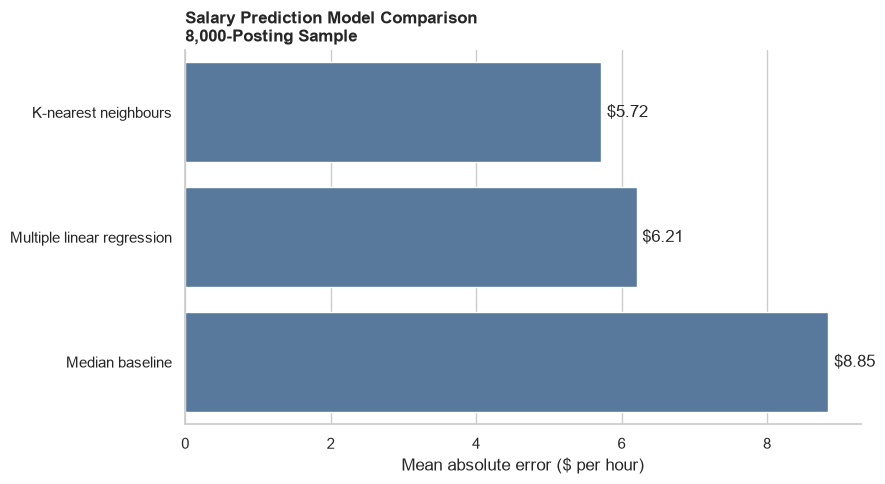

In [ ]:
comparison_plot_data = (
    knn_comparison_results
    .sort_values("MAE", ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=comparison_plot_data,
    x="MAE",
    y="Model",
    color="#4C78A8",
    ax=ax
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="$%.2f",
        padding=4
    )

ax.set_title(
    "Salary Prediction Model Comparison\n8,000-Posting Sample",
    loc="left",
    fontweight="bold"
)
ax.set_xlabel("Mean absolute error ($ per hour)")
ax.set_ylabel("")

sns.despine()
plt.tight_layout()

comparison_figure_path = Path(
    "../reports/figures/salary_model_mae_comparison.png"
)

comparison_figure_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

plt.savefig(
    comparison_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
comparison_results_path = Path(
    "../reports/salary_model_comparison.csv"
)

knn_comparison_results.to_csv(
    comparison_results_path,
    index=False
)

print(comparison_results_path.resolve())
print(comparison_results_path.exists())

C:\Users\vijda\OneDrive\Desktop\DSI_Class\repos\canadian-job-market-intelligence\reports\salary_model_comparison.csv
True


## Feature Importance

Permutation importance measures how much the model's prediction error increases when each feature is randomly shuffled. A larger increase in MAE indicates that the model relies more heavily on that feature.

In [ ]:
from sklearn.inspection import permutation_importance

knn_permutation_importance = permutation_importance(
    knn_search.best_estimator_,
    X_knn_test,
    y_knn_test,
    scoring="neg_mean_absolute_error",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

knn_feature_importance = pd.DataFrame({
    "Feature": knn_feature_columns,
    "MAE increase": knn_permutation_importance.importances_mean,
    "Standard deviation": knn_permutation_importance.importances_std
})

knn_feature_importance = (
    knn_feature_importance
    .sort_values("MAE increase", ascending=False)
    .reset_index(drop=True)
)

knn_feature_importance.round(3)

,Feature,MAE increase,Standard deviation
0,noc_major_group,3.778,0.051
1,province_territory,0.999,0.029
2,education_los,0.503,0.034
3,employment_term,0.438,0.032
4,employment_type,0.415,0.011
5,experience_level,0.366,0.034
6,vacancy_count,0.250,0.017


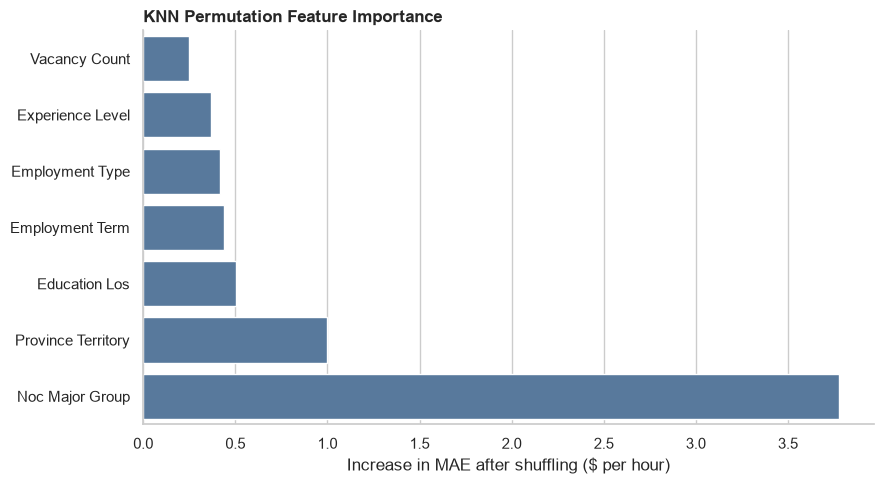

In [ ]:
importance_plot_data = (
    knn_feature_importance
    .sort_values("MAE increase", ascending=True)
    .copy()
)

importance_plot_data["Feature"] = (
    importance_plot_data["Feature"]
    .str.replace("_", " ")
    .str.title()
)

fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=importance_plot_data,
    x="MAE increase",
    y="Feature",
    color="#4C78A8",
    ax=ax
)

ax.set_title(
    "KNN Permutation Feature Importance",
    loc="left",
    fontweight="bold"
)
ax.set_xlabel("Increase in MAE after shuffling ($ per hour)")
ax.set_ylabel("")

sns.despine()
plt.tight_layout()

importance_figure_path = Path(
    "../reports/figures/knn_feature_importance.png"
)

plt.savefig(
    importance_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Feature-Importance Findings

The occupation's NOC major group was the most influential feature in the KNN model. Shuffling this feature increased the model's MAE by approximately $3.80 per hour.

Province or territory was the second most influential feature, increasing MAE by approximately $1.00 per hour when shuffled.

Employment conditions, education, experience, and vacancy count had smaller effects. This suggests that occupation and geographic location were the strongest predictors of advertised salary in this model.

Feature importance describes what the model relied on for its predictions; it does not prove that these features directly cause salary differences.